# Shap tests using different datasets

In [16]:
import numpy as np
import pandas as pd
import sklearn as skl
import zipfile as zf
import matplotlib.pyplot as plt
import nbimporter
import shap

# Iris dataset

In [2]:
import sklearn.datasets

iris= sklearn.datasets.load_iris()

X_iris= iris.data
Y_iris= iris.target

In [3]:
# convert iris to a df and drop the setosa rows
df_iris= pd.DataFrame(data= np.c_[X_iris, Y_iris], columns= iris['feature_names'] + ['target'])
df_iris= df_iris[df_iris['target']!= 0].reset_index(drop= True)

#df_iris

In [4]:
# split df_iris into features (x) and target (y)
df_iris_x= df_iris.loc[:,df_iris.columns[0:4]]
df_iris_y= df_iris.loc[:,df_iris.columns[4:5]]

<Figure size 432x288 with 0 Axes>

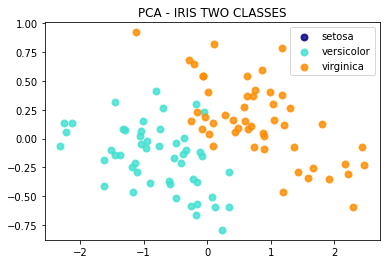

<Figure size 432x288 with 0 Axes>

In [5]:
# visualizing the new dataset using PCA
from sklearn.decomposition import PCA

X_iris= df_iris_x.to_numpy()
Y_iris= np.concatenate(df_iris_y.to_numpy())

pca= PCA(n_components= 2)
X_pca= pca.fit(X_iris).transform(X_iris)

colors= ['navy', 'turquoise', 'darkorange']

for color, i, target_name in zip(colors, [0, 1, 2], iris.target_names):
    plt.scatter(X_pca[Y_iris == i, 0], X_pca[Y_iris == i, 1], color=color, alpha=.8, lw=2, label=target_name)
    
plt.legend(loc='best', shadow=False, scatterpoints=1)
plt.title('PCA - IRIS TWO CLASSES')
plt.figure()

In [6]:
# ML model - Random forest
import sklearn.ensemble

train, test, labels_train, labels_test= sklearn.model_selection.train_test_split(df_iris_x,df_iris_y,train_size=0.80,random_state=1234)

rf= sklearn.ensemble.RandomForestClassifier(n_estimators=500,n_jobs=2)
rf.fit(train, labels_train.values.ravel())
rf_acc= sklearn.metrics.accuracy_score(labels_test, rf.predict(test))

rf_acc

0.85

In [10]:
# ML model - XGBoost random forest
import xgboost as xgb

xgb_model= xgb.XGBRFClassifier(n_estimators=500,eval_metric='logloss')
xgb_model.fit(train, labels_train.values.ravel())
xgb_acc= sklearn.metrics.accuracy_score(labels_test, xgb_model.predict(test))

xgb_acc

0.85

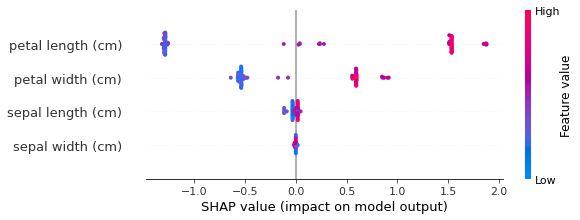

In [11]:
# SHAP
explainer= shap.Explainer(xgb_model)
shap_values= explainer(train)

shap.plots.beeswarm(shap_values)

# Titanic dataset

In [37]:
ds= zf.ZipFile('datasets/titanic.zip')

train_data= pd.read_csv(ds.open('train.csv'))
test_data= pd.read_csv(ds.open('test.csv'))

X_all= pd.concat([train_data[['PassengerId','Pclass','Sex','Age','SibSp','Parch','Fare','Embarked']],
                   test_data[['PassengerId','Pclass','Sex','Age','SibSp','Parch','Fare','Embarked']]]).set_index('PassengerId')

y_train= train_data[['PassengerId','Survived']].set_index('PassengerId')['Survived']

numeric_columns= ['Age','SibSp','Parch','Fare']
categor_columns= list(filter(lambda x:x not in numeric_columns,X_all.columns))

X_train= X_all.iloc[:len(train_data),:].copy()
X_test= X_all.iloc[len(train_data):].copy()

In [29]:
import Ft_Att_Rank as far

X_train= far.pre_proc_fillna_num_fts(X_train,numeric_columns,num_type='median')
X_train= far.pre_proc_fillna_cat_fts(X_train,categor_columns,cat_type='mode')

X_train_ohe= pd.get_dummies(X_train,columns=categor_columns)

X_train= far.normalize_selected_cols(X_train, numeric_columns)
X_train_ohe= far.normalize_selected_cols(X_train_ohe, numeric_columns)

In [34]:
# ML model - XGBoost random forest
train, test, labels_train, labels_test= sklearn.model_selection.train_test_split(X_train_ohe,y_train,train_size=0.80,random_state=1234)

xgb_model= xgb.XGBRFClassifier(n_estimators=500,eval_metric='logloss',use_label_encoder=False)
xgb_model.fit(train, labels_train.values.ravel())
xgb_acc= sklearn.metrics.accuracy_score(labels_test, xgb_model.predict(test))

xgb_acc

0.8379888268156425

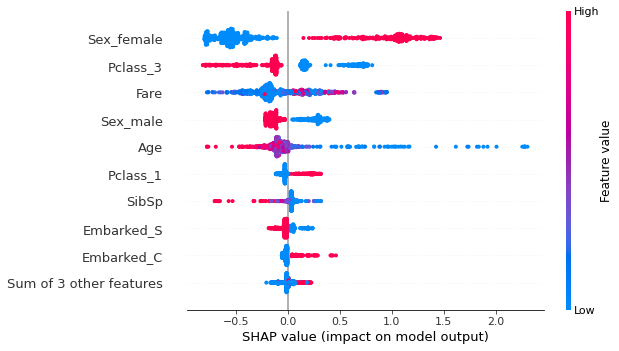

In [36]:
# SHAP
explainer= shap.Explainer(xgb_model)
shap_values= explainer(train)

shap.plots.beeswarm(shap_values)

# Drug consumption dataset

# Heartrisk dataset

# Breast cancer Wisconsin dataset

# Arrhythmia dataset